In [5]:
import os 
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")

In [6]:
!pwd

/home/hakimmics/projects/ph_vae


In [7]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from scipy.stats import t
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import weibull_min
import plotly.graph_objects as go
from utils.ph import *
import pandas as pd
from models.ph_vae import *


In [8]:
df = pd.read_csv('data/Danish_Fire_Insurance_Claims_734_59.csv')
data = df['dat'].to_numpy()
data = data/100

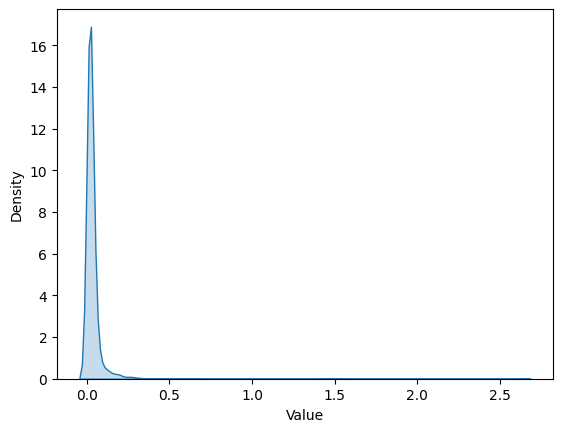

In [9]:


sns.kdeplot(data, fill=True,)
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()
# creating the dataset
tensor_x = torch.tensor(data, dtype=torch.float32).view(-1, 1)
dataset = TensorDataset(tensor_x)
train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

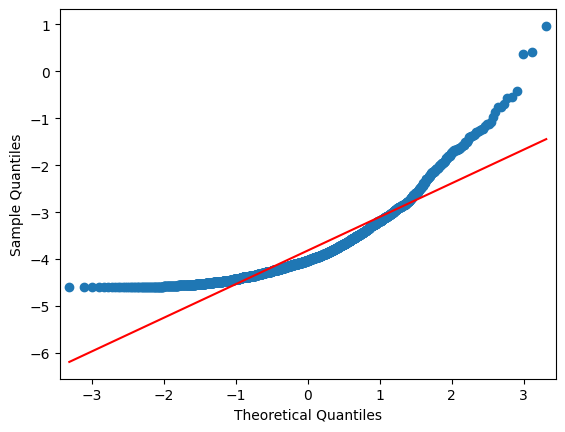

In [10]:
import statsmodels.api as sm
sm.qqplot(np.log(data+1e-6), line='s')
plt.show()


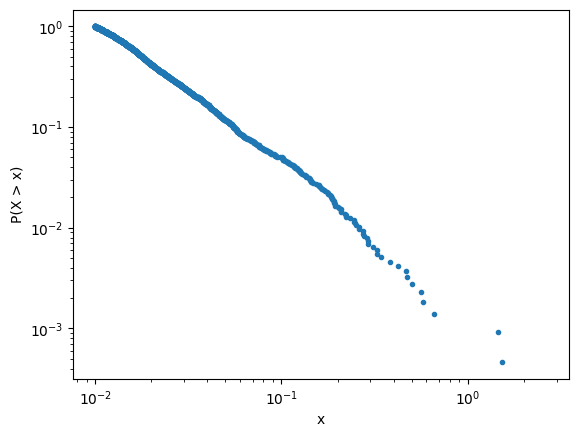

In [11]:
x = np.sort(data)
ccdf = 1.0 - np.arange(1, len(x)+1) / len(x)

plt.loglog(x, ccdf, marker='.', linestyle='none')
plt.xlabel("x")
plt.ylabel("P(X > x)")
plt.show()

# PHVAE

In [15]:
model= MultiDimPHVAE(input_dim=1, latent_dim=15, n_phases=10)
train_phvae(
    model,
    train_loader,
    epochs=13,
    learning_rate=1e-2,
    beta=1,           
    grad_clip=1.0,
    reduce_lr=False,
)

Using device: cpu


/home/hakimmics/myenv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch 1/13:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 001 | Loss: -0.1175 | Recon: 1.3712 | KL: 1.2538 | Time/epoch: 0.33s


Epoch 2/13:   0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 12/13:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 012 | Loss: -2.5069 | Recon: 2.5070 | KL: 0.0001 | Time/epoch: 0.13s


Epoch 13/13:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 013 | Loss: -2.5072 | Recon: 2.5073 | KL: 0.0001 | Time/epoch: 0.13s

Total training time: 1.91s (0.15s/epoch avg)
Mean time/epoch: 0.15 ± 0.06 s


{'focus_metric': [-1.371227023125135,
  -2.4047239723434415,
  -2.4744941909906224,
  -2.4908445512967887,
  -2.501357622723124,
  -2.505403473457544,
  -2.5046972855478593,
  -2.505423470141979,
  -2.5087503054530376,
  -2.5078823702864566,
  -2.508496238165425,
  -2.507044801967288,
  -2.5073351465065907],
 'epoch_times': tensor([0.3317, 0.1482, 0.1047, 0.1055, 0.1222, 0.1264, 0.1200, 0.1243, 0.1286,
         0.1534, 0.1773, 0.1300, 0.1322])}

In [ ]:
model.eval()
N = data.shape[0]
device = next(model.parameters()).device
with torch.no_grad():
    # sample latents
    z = torch.randn(N, model.latent_dim, device=device)
    alpha, T, t = model.decode_params(z) 
    ph_samples = ph_sample_batch(alpha, T, t).cpu().numpy()

#
# reset data transformation
data_real = data * 100
ph_samples = ph_samples * 100


n_bins= 1000
hist_data = go.Histogram(
    x=data_real,
    name='Real Data',
    opacity=0.7,
    nbinsx=n_bins,  
    marker_color='#4C72B0'
)

# Create histogram for ph_samples
hist_samples = go.Histogram(
    x=ph_samples,
    name='PH Samples',
    opacity=0.7,
    nbinsx=n_bins,
    marker_color='#DD8452'
)

# Combine them
fig = go.Figure(data=[hist_data, hist_samples])

# Update layout for a publication-ready style
fig.update_layout(
    title_text="PH-VAE generations vs Weibull",
    title_font_size=30,
    #xaxis_title="x",
    #yaxis_title="Density",
    yaxis_type="log",  # Set y-axis to log scale
    font=dict(
        family="serif",  # Use a serif font
        size=30,         # Base font size
        color="black"
    ),
    legend=dict(
        x=0.98, # Place legend in top right corner
        y=0.98,
        xanchor='right',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.7)', # Semi-transparent background
        bordercolor='black',
        borderwidth=1,
        font_size=30
    ),
    plot_bgcolor='white', # White background
    # Remove fixed width/height to allow scalable export
    # width=800,
    # height=500,
    margin=dict(l=50, r=20, t=50, b=50) # Adjust margins
)

# Add prominent axis lines and updated gridlines
fig.update_xaxes(
    showline=True,  # Show x-axis line
    linewidth=1.5,
    linecolor='black',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(200, 200, 200, 0.5)' # Lighter gray grid
)
fig.update_yaxes(
    showline=True,  # Show y-axis line
    linewidth=1.5,
    linecolor='black',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(200, 200, 200, 0.5)' # Lighter gray grid
)

fig.show()

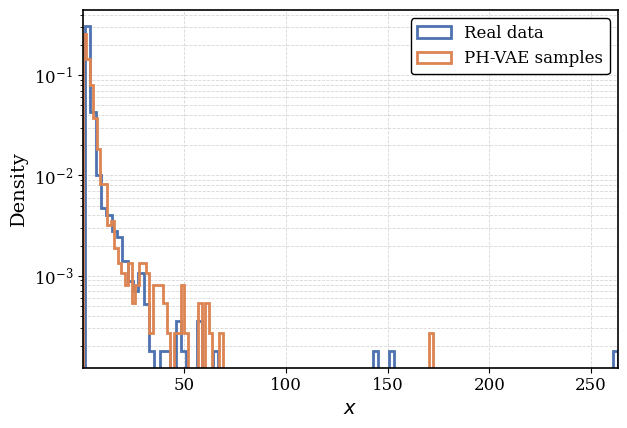

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Global ICML-style parameters

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})


# Create figure

fig, ax = plt.subplots(figsize=(6.5, 4.5))  # ICML column-friendly size

# Number of bins
n_bins = 100


# Histograms (density!)

ax.hist(
    data_real,
    bins=n_bins,
    density=True,
    histtype="step",
    linewidth=2.0,
    color="#4C72B0",
    label="Real data"
)

ax.hist(
    ph_samples,
    bins=n_bins,
    density=True,
    histtype="step",
    linewidth=2.0,
    color="#DD8452",
    label="PH-VAE samples"
)
plt.xlim(0,100)

# Axes settings

ax.set_yscale("log")

ax.set_xlabel(r"$x$")
ax.set_ylabel("Density")

# Axis limits (optional but recommended for stability)
ax.set_xlim(min(data_real.min(), ph_samples.min()),
            max(data_real.max(), ph_samples.max()))


# Grid (ICML-light)

ax.grid(
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)


# Legend (top-right, clean)

ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=1.0,
    edgecolor="black"
)


# Tight layout

plt.tight_layout()

plt.show()


In [ ]:
def empirical_quantiles(x):
    return {
        "q95": np.quantile(x, 0.95),
        "q99": np.quantile(x, 0.99),
        "q995": np.quantile(x, 0.995),
    }

emp_q = empirical_quantiles(data)
def ks_distance(data, model_samples):
    data = np.sort(data)
    model_samples = np.sort(model_samples)

    # Empirical CDFs
    F_data = np.arange(1, len(data)+1) / len(data)
    F_model = np.arange(1, len(model_samples)+1) / len(model_samples)

    # Interpolate model CDF on data points
    F_model_interp = np.interp(data, model_samples, F_model)

    return np.max(np.abs(F_data - F_model_interp))


def ks_tail(data, model_samples, q=0.95):
    thr = np.quantile(data, q)

    d_tail = data[data >= thr]
    m_tail = model_samples[model_samples >= thr]

    if len(m_tail) == 0:
        return np.nan

    # Conditional CDFs (renormalized)
    d_tail = np.sort(d_tail)
    m_tail = np.sort(m_tail)

    Fd = np.arange(1, len(d_tail)+1) / len(d_tail)
    Fm = np.arange(1, len(m_tail)+1) / len(m_tail)

    Fm_interp = np.interp(d_tail, m_tail, Fm)

    return np.max(np.abs(Fd - Fm_interp))
def quantile_errors(data, model_samples):
    q_data = empirical_quantiles(data)
    q_mod = empirical_quantiles(model_samples)

    return {
        "q95_err": (q_mod["q95"] - q_data["q95"]) / q_data["q95"],
        "q99_err": (q_mod["q99"] - q_data["q99"]) / q_data["q99"],
        "q995_err": (q_mod["q995"] - q_data["q995"]) / q_data["q995"],
    }
results = {
    "KS_full": ks_distance(data, ph_samples),
    "KS_tail": ks_tail(data, ph_samples, q=0.95),
}
results.update(quantile_errors(data, ph_samples))

print("\n=== Results for model ===")
for k, v in results.items():
    print(f"{k:10s}: {v:.4f}")



=== Results for model ===
KS_full   : 0.9252
KS_tail   : 0.8143
q95_err   : 110.6361
q99_err   : 137.5402
q995_err  : 133.8586


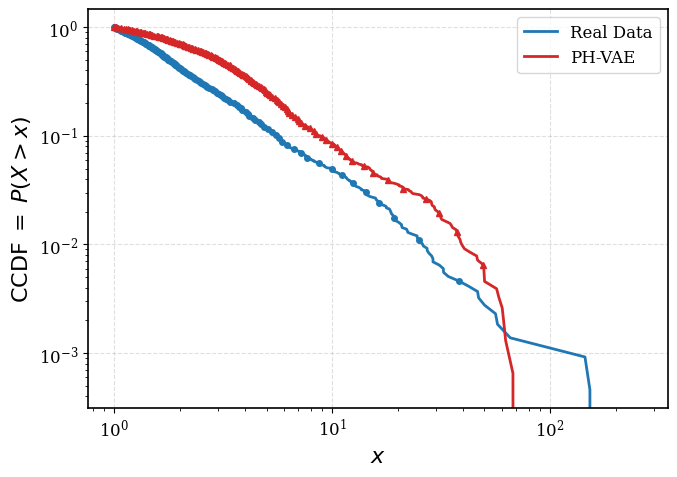

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.size']   = 14
rcParams['lines.linewidth'] = 2.0

def ccdf_curve(x):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    ccdf = 1.0 - np.arange(1, n+1) / n
    return x_sorted, ccdf

# Compute curves
x_real, ccdf_real = ccdf_curve(data_real)
x_ph,   ccdf_ph   = ccdf_curve(ph_samples[ph_samples>1])

plt.figure(figsize=(7,5))

# --- Real data ---
step = max(1, len(x_real) // 150)  # ≈150 markers max
plt.loglog(
    x_real, ccdf_real,
    color="#1f77b4",
    label="Real Data"
)
plt.loglog(
    x_real[::step], ccdf_real[::step],
    marker='o', linestyle='none', markersize=4, color="#1f77b4"
)

# --- PH-VAE ---
step2 = max(1, len(x_ph) // 150)
plt.loglog(
    x_ph, ccdf_ph,
    color="#d62728",
    label="PH-VAE"
)
plt.loglog(
    x_ph[::step2], ccdf_ph[::step2],
    marker='^', linestyle='none', markersize=4, color="#d62728"
)

plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$\mathrm{CCDF}\;=\;P(X>x)$", fontsize=16)
plt.grid(True, which="major", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm


config = {
    "input_dim": 1,
    "latent_dim": 5,
    "hidden_dim": 8,
    "epochs": 600,
    "batch_size": 256,
    "learning_rate": 1e-3,
}

device = "cuda" if torch.cuda.is_available() else "cpu"


x_log = torch.log(tensor_x + 1e-6)        # tensor_x = original positive data
mean = x_log.mean()
std = x_log.std()
x_log = (x_log - mean) / std
dataset = TensorDataset(x_log)
train_loader = DataLoader(
    dataset,
    batch_size=config["batch_size"],
    shuffle=True
)


class LogGaussianVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        self.enc1 = nn.Linear(input_dim, hidden_dim)
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.dec1 = nn.Linear(latent_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, input_dim)  # predicts log x

    def encode(self, x):
        h = F.relu(self.enc1(x))
        h = F.relu(self.enc2(h))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec1(z))
        h = F.relu(self.dec2(h))
        return self.out(h)   # log x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_logx = self.decode(z)
        return recon_logx, mu, logvar



def vae_loss(recon_logx, logx, mu, logvar):
    recon = F.mse_loss(recon_logx, logx, reduction="sum")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon +1* kl, recon, kl



modelg = LogGaussianVAE(
    config["input_dim"],
    config["latent_dim"],
    config["hidden_dim"]
).to(device)

optimizer = torch.optim.Adam(modelg.parameters(), lr=config["learning_rate"])

for epoch in range(config["epochs"]):
    modelg.train()
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)

        recon_logx, mu, logvar = modelg(x_batch)
        loss, rec, kl = vae_loss(recon_logx, x_batch, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss.item():.4f} | "
            f"Recon {rec.item():.4f} | "
            f"KL {kl.item():.4f}"
        )


Epoch 000 | Loss 103.4372 | Recon 103.3608 | KL 0.0764
Epoch 010 | Loss 75.8130 | Recon 75.6638 | KL 0.1492
Epoch 020 | Loss 20.1423 | Recon 19.4290 | KL 0.7133
Epoch 030 | Loss 7.0012 | Recon 5.7886 | KL 1.2127
Epoch 040 | Loss 4.9868 | Recon 3.6051 | KL 1.3816
Epoch 050 | Loss 2.7696 | Recon 1.3541 | KL 1.4155
Epoch 060 | Loss 2.5047 | Recon 0.7699 | KL 1.7348
Epoch 070 | Loss 2.4774 | Recon 0.6809 | KL 1.7965
Epoch 080 | Loss 2.2856 | Recon 0.5294 | KL 1.7562
Epoch 090 | Loss 1.9530 | Recon 0.4014 | KL 1.5516
Epoch 100 | Loss 2.0576 | Recon 0.3818 | KL 1.6758
Epoch 110 | Loss 1.7562 | Recon 0.2082 | KL 1.5480
Epoch 120 | Loss 1.7049 | Recon 0.2476 | KL 1.4573
Epoch 130 | Loss 1.7783 | Recon 0.2324 | KL 1.5459
Epoch 140 | Loss 1.6711 | Recon 0.1584 | KL 1.5127
Epoch 150 | Loss 1.6789 | Recon 0.2382 | KL 1.4408
Epoch 160 | Loss 1.5487 | Recon 0.2219 | KL 1.3268
Epoch 170 | Loss 1.7106 | Recon 0.1811 | KL 1.5296
Epoch 180 | Loss 1.5078 | Recon 0.1391 | KL 1.3687
Epoch 190 | Loss 1.4545

In [ ]:
# %% [code]
import numpy as np

modelg.eval()
N = len(data_real)   # same size as dataset

with torch.no_grad():
    z = torch.randn(N, config["latent_dim"]).to(device)
    log_x = modelg.decode(z)
    log_x = log_x * std + mean  
    vae_samples = torch.exp(log_x).cpu().numpy().flatten()
    vae_samples = vae_samples *100
# Sanity checks
print("min:", vae_samples.min())
print("q95:", np.quantile(vae_samples, 0.95))
print("q99:", np.quantile(vae_samples, 0.99))
print("max:", vae_samples.max())


min: 0.5863042
q95: 5.626379
q99: 8.73612
max: 13.491667


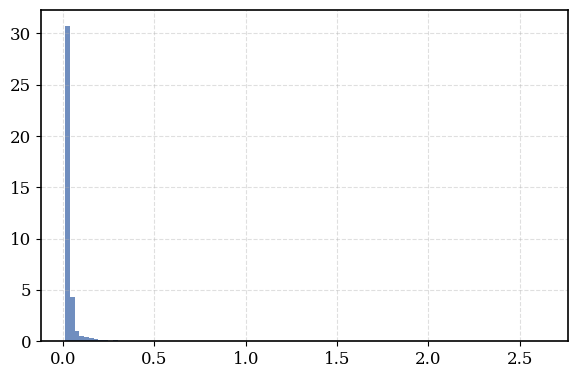

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(
    tensor_x.numpy().flatten(),
    bins=100,
    density=True,
    color="#4C72B0",
    alpha=0.8, 

)
# plt.xscale('log')
# plt.yscale('log')
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

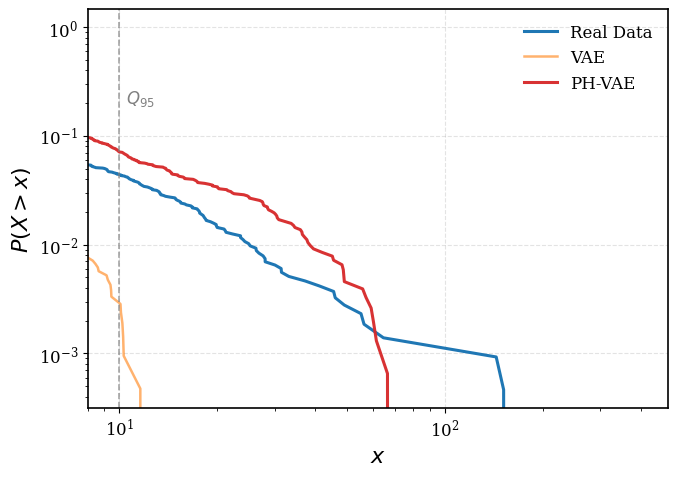

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --- ICML-style params ---
rcParams['font.family'] = 'serif'
rcParams['font.size']   = 14
rcParams['lines.linewidth'] = 2.2

def ccdf_curve(x):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    ccdf = 1.0 - np.arange(1, n+1) / n
    return x_sorted, ccdf


x_real, ccdf_real = ccdf_curve(data_real)
x_ph,   ccdf_ph   = ccdf_curve(ph_samples)
x_vae,  ccdf_vae  = ccdf_curve(vae_samples)
# --- support alignment ---
xmin = data_real.min()

data_real_s = data_real - xmin
ph_samples_s = ph_samples - xmin
vae_samples_s = vae_samples - xmin

# safety (numerical)
data_real_s = data_real_s[data_real_s > 0]
ph_samples_s = ph_samples_s[ph_samples_s > 0]
vae_samples_s = vae_samples_s[vae_samples_s > 0]

# --- CCDFs ---
x_real, ccdf_real = ccdf_curve(data_real_s)
x_ph,   ccdf_ph   = ccdf_curve(ph_samples_s)
x_vae,  ccdf_vae  = ccdf_curve(vae_samples_s)

plt.figure(figsize=(7,5))

# --- Real data (reference) ---
step = max(1, len(x_real)//120)
plt.loglog(x_real, ccdf_real, color="#1f77b4", label="Real Data")
# plt.loglog(
#     x_real[::step], ccdf_real[::step],
#     linestyle="none", marker="o", markersize=4,
#     color="#1f77b4"
# )

# --- VAE (baseline, de-emphasized but visible) ---
plt.loglog(
    x_vae, ccdf_vae,
    color="#ff7f0e",
    alpha=0.6,
    linewidth=1.8,
    label="VAE"
)

# --- PH-VAE (hero) ---
step2 = max(1, len(x_ph)//120)
plt.loglog(x_ph,ccdf_ph, alpha=0.95, color="#d62728", label="PH-VAE")
# plt.loglog(
#     x_ph[::step2], ccdf_ph[::step2],
#     linestyle="none", marker="^", markersize=4,
#     color="#d62728"
# )

# --- Tail marker (NO zooming) ---
q95 = np.quantile(data_real, 0.95)
plt.axvline(
    q95, color="gray", linestyle="--", linewidth=1.2, alpha=0.7
)
plt.text(
    q95*1.05, 2e-1, r"$Q_{95}$",
    fontsize=12, color="gray"
)

plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$P(X > x)$", fontsize=16)
plt.xlim(left=8)
plt.grid(True, which="major", linestyle="--", alpha=0.35)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
results = {
    "KS_full": ks_distance(data, vae_samples),
    "KS_tail": ks_tail(data, vae_samples, q=0.95),
}
results.update(quantile_errors(data, vae_samples))

print("\n=== Results for model ===")
for k, v in results.items():
    print(f"{k:10s}: {v:.4f}")



=== Results for model ===
KS_full   : 0.9977
KS_tail   : 0.9711
q95_err   : 55.4181
q99_err   : 32.5456
q995_err  : 28.1345



=== Summary tail metrics (mean ± std over seeds) ===
       Model              Seeds     TailQuantile_MAE    TailQuantile_MRE      ExceedProb_MAE    LogExceedProb_MAE          LogCCDF_L1         LogCCDF_RMSE             CVaR_MAE            CVaR_MRE
      PH-VAE [0, 1, 2, 3, 4, 5] 13.485431 ± 3.035199 0.347531 ± 0.059139 0.017638 ± 0.002822  1.098177 ± 1.307562 0.441337 ± 0.140021  0.759861 ± 0.737965 11.605284 ± 7.002098 0.218150 ± 0.112532
Gaussian-VAE [0, 1, 2, 3, 4, 5] 29.206006 ± 0.158801 0.573305 ± 0.007201 0.020612 ± 0.000538 14.359440 ± 1.553211 6.451017 ± 0.778736 10.995089 ± 1.014024 46.148452 ± 0.199618 0.779771 ± 0.004247

=== Tail quantile table (mean ± std over seeds) ===
    q     Q_true            PH_abs_err           VAE_abs_err          PH_rel_err         VAE_rel_err
0.900   5.541526   1.917564 ± 0.292374   0.946530 ± 0.080955 0.346035 ± 0.052761 0.170807 ± 0.014609
0.950   9.972647   1.296263 ± 0.522190   4.220441 ± 0.088049 0.129982 ± 0.052362 0.423202 ± 0.008829
0.

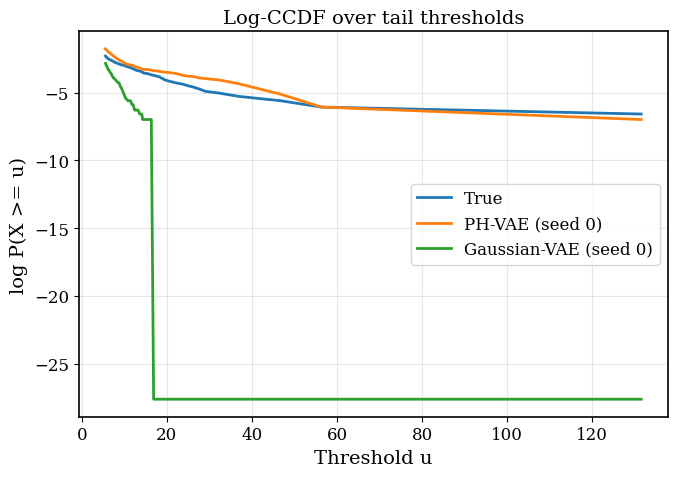

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

seeds = [0, 1, 2, 3, 4, 5]

x_true = np.asarray(data_real).reshape(-1)
N = len(x_true)


# Helpers

def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def safe_quantile(x, q):
    return np.quantile(x, q)

def cvar(x, q):
    u = np.quantile(x, q)
    tail = x[x >= u]
    if len(tail) == 0:
        return np.nan
    return tail.mean()

def exceedance_prob(x, u):
    return np.mean(x >= u)

def ccdf_on_thresholds(x, thresholds):
    return np.array([np.mean(x >= u) for u in thresholds])

def fmt_mean_std(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return "nan ± nan"
    return f"{vals.mean():.6f} ± {vals.std(ddof=0):.6f}"

def sample_ph_vae(n_samples):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, model.latent_dim, device=device)
        alpha, T, t = model.decode_params(z)
        s = ph_sample_batch(alpha, T, t).cpu().numpy().reshape(-1)
    return s * 100.0

def sample_gaussian_vae(n_samples):
    modelg.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, config["latent_dim"], device=device)
        log_x = modelg.decode(z)
        log_x = log_x * std + mean
        s = torch.exp(log_x).cpu().numpy().reshape(-1)
    return s * 100.0


# Metric grids

q_grid = np.array([0.90, 0.95, 0.98, 0.99, 0.995, 0.999])
q_true = np.array([safe_quantile(x_true, q) for q in q_grid])
u_grid = q_true.copy()

thr_grid = np.quantile(x_true, np.linspace(0.90, 0.999, 80))
ccdf_true = ccdf_on_thresholds(x_true, thr_grid)

cvar_grid = np.array([0.95, 0.99, 0.995])
cvar_true = np.array([cvar(x_true, q) for q in cvar_grid])


# Collect per-seed metrics

ph_seed_metrics = []
vae_seed_metrics = []

ph_q_rel_err_all = []
vae_q_rel_err_all = []
ph_q_abs_err_all = []
vae_q_abs_err_all = []

ph_cvar_rel_err_all = []
vae_cvar_rel_err_all = []
ph_cvar_abs_err_all = []
vae_cvar_abs_err_all = []

for s in seeds:
    set_all_seeds(s)
    x_ph = sample_ph_vae(N)
    x_vae = sample_gaussian_vae(N)

    q_ph = np.array([safe_quantile(x_ph, q) for q in q_grid])
    q_vae = np.array([safe_quantile(x_vae, q) for q in q_grid])

    ph_abs_err_q = np.abs(q_ph - q_true)
    vae_abs_err_q = np.abs(q_vae - q_true)
    ph_rel_err_q = ph_abs_err_q / (q_true + 1e-12)
    vae_rel_err_q = vae_abs_err_q / (q_true + 1e-12)

    p_true = np.array([exceedance_prob(x_true, u) for u in u_grid])
    p_ph = np.array([exceedance_prob(x_ph, u) for u in u_grid])
    p_vae = np.array([exceedance_prob(x_vae, u) for u in u_grid])

    ph_exc_mae = np.mean(np.abs(p_ph - p_true))
    vae_exc_mae = np.mean(np.abs(p_vae - p_true))

    ph_logexc_mae = np.mean(np.abs(np.log(p_ph + 1e-12) - np.log(p_true + 1e-12)))
    vae_logexc_mae = np.mean(np.abs(np.log(p_vae + 1e-12) - np.log(p_true + 1e-12)))

    ccdf_ph = ccdf_on_thresholds(x_ph, thr_grid)
    ccdf_vae = ccdf_on_thresholds(x_vae, thr_grid)

    ph_logccdf_l1 = np.mean(np.abs(np.log(ccdf_ph + 1e-12) - np.log(ccdf_true + 1e-12)))
    vae_logccdf_l1 = np.mean(np.abs(np.log(ccdf_vae + 1e-12) - np.log(ccdf_true + 1e-12)))

    ph_logccdf_l2 = np.sqrt(np.mean((np.log(ccdf_ph + 1e-12) - np.log(ccdf_true + 1e-12)) ** 2))
    vae_logccdf_l2 = np.sqrt(np.mean((np.log(ccdf_vae + 1e-12) - np.log(ccdf_true + 1e-12)) ** 2))

    cvar_ph = np.array([cvar(x_ph, q) for q in cvar_grid])
    cvar_vae = np.array([cvar(x_vae, q) for q in cvar_grid])

    ph_abs_err_c = np.abs(cvar_ph - cvar_true)
    vae_abs_err_c = np.abs(cvar_vae - cvar_true)
    ph_rel_err_c = ph_abs_err_c / (cvar_true + 1e-12)
    vae_rel_err_c = vae_abs_err_c / (cvar_true + 1e-12)

    ph_seed_metrics.append({
        "TailQuantile_MAE": ph_abs_err_q.mean(),
        "TailQuantile_MRE": ph_rel_err_q.mean(),
        "ExceedProb_MAE": ph_exc_mae,
        "LogExceedProb_MAE": ph_logexc_mae,
        "LogCCDF_L1": ph_logccdf_l1,
        "LogCCDF_RMSE": ph_logccdf_l2,
        "CVaR_MAE": ph_abs_err_c.mean(),
        "CVaR_MRE": ph_rel_err_c.mean(),
    })

    vae_seed_metrics.append({
        "TailQuantile_MAE": vae_abs_err_q.mean(),
        "TailQuantile_MRE": vae_rel_err_q.mean(),
        "ExceedProb_MAE": vae_exc_mae,
        "LogExceedProb_MAE": vae_logexc_mae,
        "LogCCDF_L1": vae_logccdf_l1,
        "LogCCDF_RMSE": vae_logccdf_l2,
        "CVaR_MAE": vae_abs_err_c.mean(),
        "CVaR_MRE": vae_rel_err_c.mean(),
    })

    ph_q_abs_err_all.append(ph_abs_err_q)
    vae_q_abs_err_all.append(vae_abs_err_q)
    ph_q_rel_err_all.append(ph_rel_err_q)
    vae_q_rel_err_all.append(vae_rel_err_q)

    ph_cvar_abs_err_all.append(ph_abs_err_c)
    vae_cvar_abs_err_all.append(vae_abs_err_c)
    ph_cvar_rel_err_all.append(ph_rel_err_c)
    vae_cvar_rel_err_all.append(vae_rel_err_c)

ph_seed_metrics = pd.DataFrame(ph_seed_metrics)
vae_seed_metrics = pd.DataFrame(vae_seed_metrics)

ph_q_abs_err_all = np.vstack(ph_q_abs_err_all)
vae_q_abs_err_all = np.vstack(vae_q_abs_err_all)
ph_q_rel_err_all = np.vstack(ph_q_rel_err_all)
vae_q_rel_err_all = np.vstack(vae_q_rel_err_all)

ph_cvar_abs_err_all = np.vstack(ph_cvar_abs_err_all)
vae_cvar_abs_err_all = np.vstack(vae_cvar_abs_err_all)
ph_cvar_rel_err_all = np.vstack(ph_cvar_rel_err_all)
vae_cvar_rel_err_all = np.vstack(vae_cvar_rel_err_all)


# Final summary table (mean ± std)

summary = pd.DataFrame([
    {
        "Model": "PH-VAE",
        "Seeds": str(seeds),
        "TailQuantile_MAE": fmt_mean_std(ph_seed_metrics["TailQuantile_MAE"]),
        "TailQuantile_MRE": fmt_mean_std(ph_seed_metrics["TailQuantile_MRE"]),
        "ExceedProb_MAE": fmt_mean_std(ph_seed_metrics["ExceedProb_MAE"]),
        "LogExceedProb_MAE": fmt_mean_std(ph_seed_metrics["LogExceedProb_MAE"]),
        "LogCCDF_L1": fmt_mean_std(ph_seed_metrics["LogCCDF_L1"]),
        "LogCCDF_RMSE": fmt_mean_std(ph_seed_metrics["LogCCDF_RMSE"]),
        "CVaR_MAE": fmt_mean_std(ph_seed_metrics["CVaR_MAE"]),
        "CVaR_MRE": fmt_mean_std(ph_seed_metrics["CVaR_MRE"]),
    },
    {
        "Model": "Gaussian-VAE",
        "Seeds": str(seeds),
        "TailQuantile_MAE": fmt_mean_std(vae_seed_metrics["TailQuantile_MAE"]),
        "TailQuantile_MRE": fmt_mean_std(vae_seed_metrics["TailQuantile_MRE"]),
        "ExceedProb_MAE": fmt_mean_std(vae_seed_metrics["ExceedProb_MAE"]),
        "LogExceedProb_MAE": fmt_mean_std(vae_seed_metrics["LogExceedProb_MAE"]),
        "LogCCDF_L1": fmt_mean_std(vae_seed_metrics["LogCCDF_L1"]),
        "LogCCDF_RMSE": fmt_mean_std(vae_seed_metrics["LogCCDF_RMSE"]),
        "CVaR_MAE": fmt_mean_std(vae_seed_metrics["CVaR_MAE"]),
        "CVaR_MRE": fmt_mean_std(vae_seed_metrics["CVaR_MRE"]),
    }
])


# Tail quantile table (mean ± std)

quantile_rows = []
for i, q in enumerate(q_grid):
    quantile_rows.append({
        "q": q,
        "Q_true": f"{q_true[i]:.6f}",
        "PH_abs_err": fmt_mean_std(ph_q_abs_err_all[:, i]),
        "VAE_abs_err": fmt_mean_std(vae_q_abs_err_all[:, i]),
        "PH_rel_err": fmt_mean_std(ph_q_rel_err_all[:, i]),
        "VAE_rel_err": fmt_mean_std(vae_q_rel_err_all[:, i]),
    })
quantile_table = pd.DataFrame(quantile_rows)


# CVaR table (mean ± std)

cvar_rows = []
for i, q in enumerate(cvar_grid):
    cvar_rows.append({
        "q": q,
        "CVaR_true": f"{cvar_true[i]:.6f}",
        "PH_abs_err": fmt_mean_std(ph_cvar_abs_err_all[:, i]),
        "VAE_abs_err": fmt_mean_std(vae_cvar_abs_err_all[:, i]),
        "PH_rel_err": fmt_mean_std(ph_cvar_rel_err_all[:, i]),
        "VAE_rel_err": fmt_mean_std(vae_cvar_rel_err_all[:, i]),
    })
cvar_table = pd.DataFrame(cvar_rows)

print("\n=== Summary tail metrics (mean ± std over seeds) ===")
print(summary.to_string(index=False))

print("\n=== Tail quantile table (mean ± std over seeds) ===")
print(quantile_table.to_string(index=False))

print("\n=== CVaR table (mean ± std over seeds) ===")
print(cvar_table.to_string(index=False))


# Optional plots (seed 0 sample)

set_all_seeds(seeds[0])
x_ph_plot = sample_ph_vae(N)
x_vae_plot = sample_gaussian_vae(N)

ccdf_ph_plot = ccdf_on_thresholds(x_ph_plot, thr_grid)
ccdf_vae_plot = ccdf_on_thresholds(x_vae_plot, thr_grid)

plt.figure(figsize=(7, 5))
plt.plot(thr_grid, np.log(ccdf_true + 1e-12), label="True", linewidth=2)
plt.plot(thr_grid, np.log(ccdf_ph_plot + 1e-12), label="PH-VAE (seed 0)", linewidth=2)
plt.plot(thr_grid, np.log(ccdf_vae_plot + 1e-12), label="Gaussian-VAE (seed 0)", linewidth=2)
plt.xlabel("Threshold u")
plt.ylabel("log P(X >= u)")
plt.title("Log-CCDF over tail thresholds")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()